In [5]:
import os
import email

def load_emails(root_folder, label):
    data = []

    for dirpath, _, filenames in os.walk(root_folder):
        for filename in filenames:
            # CMU files do NOT end with .eml, so load everything
            file_path = os.path.join(dirpath, filename)

            try:
                with open(file_path, "r", encoding="latin-1") as f:
                    msg = email.message_from_file(f)

                body = ""

                if msg.is_multipart():
                    for part in msg.walk():
                        if part.get_content_type() == "text/plain":
                            payload = part.get_payload(decode=True)
                            if payload:
                                body += payload.decode("latin-1", errors="ignore")
                else:
                    payload = msg.get_payload(decode=True)
                    if payload:
                        body = payload.decode("latin-1", errors="ignore")

                data.append([body, label])

            except Exception as e:
                print("Error reading:", file_path, e)

    return data


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [10]:
enron_path = "../data/raw/enron/maildir"
legit_emails = load_emails(enron_path, 0)

print("Loaded legitimate emails:", len(legit_emails))


NameError: name 'load_emails' is not defined

In [11]:
legit_emails = fast_load_emails("../data/raw/enron", 0)


NameError: name 'fast_load_emails' is not defined

In [ ]:
import os

def fast_load_subset(root_dir, label, limit=10000):
    emails = []
    count = 0
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if count >= limit:
                return emails
            file_path = os.path.join(dirpath, filename)
            try:
                with open(file_path, "r", errors="ignore") as f:
                    content = f.read()
                    emails.append([content, label])
                    count += 1
            except:
                pass
    return emails

legit_emails = fast_load_subset("../data/raw/enron", 0, limit=10000)
print("Loaded subset:", len(legit_emails))


In [12]:
import pandas as pd

# Step 1 — Load Nazario phishing dataset
phish_df = pd.read_csv("../data/raw/nazario/Nazario.csv")

# Step 2 — Show first few rows and columns
print(phish_df.head())
print(phish_df.columns)

# Step 3 — Convert phishing emails into [text, label]
# Using the correct column names from your screenshot
phishing_emails = []

for email, label in zip(phish_df["body"], phish_df["label"]):
    phishing_emails.append([email, label])

print("Total phishing emails loaded:", len(phishing_emails))


                                              sender  \
0  Mail System Internal Data <MAILER-DAEMON@monke...   
1                        cPanel <service@cpanel.com>   
2    Microsoft Outlook <recepcao@unimedceara.com.br>   
3                     Ann Garcia <AnGarcia@mcoe.org>   
4                 "USAA" <usaaacctupdate@sccu4u.com>   

                                 receiver  \
0                                     NaN   
1                         jose@monkey.org   
2                                     NaN   
3     "info@maaaaa.org" <info@maaaaa.org>   
4  Recipients <usaaacctupdate@sccu4u.com>   

                                    date  \
0             28 Sep 2017 09:57:25 -0400   
1        Fri, 30 Oct 2015 00:00:48 -0500   
2  Fri, 30 Oct 2015 06:21:59 -0300 (BRT)   
3        Fri, 30 Oct 2015 14:54:33 +0000   
4        Fri, 30 Oct 2015 14:02:33 -0500   

                                             subject  \
0  DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA   
1              

In [13]:
import os

def fast_load_subset(root_dir, label, limit=10000):
    emails = []
    count = 0
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if count >= limit:
                return emails
            file_path = os.path.join(dirpath, filename)
            try:
                with open(file_path, "r", errors="ignore") as f:
                    content = f.read()
                    emails.append([content, label])
                    count += 1
            except:
                pass
    return emails

legit_emails = fast_load_subset("../data/raw/enron", 0, limit=10000)
print("Loaded subset:", len(legit_emails))


Loaded subset: 10000


In [14]:
import pandas as pd

df_legit = pd.DataFrame(legit_emails, columns=["text", "label"])
df_legit.to_csv("../data/processed/legit_emails.csv", index=False)

print("Saved legit_emails.csv")


Saved legit_emails.csv


In [15]:
df_phish = pd.DataFrame(phishing_emails, columns=["text", "label"])
df_all = pd.concat([df_legit, df_phish], ignore_index=True)

print("Total combined emails:", len(df_all))

df_all.to_csv("../data/processed/phishing_dataset.csv", index=False)


Total combined emails: 11565


In [16]:
import pandas as pd

df_all = pd.read_csv("../data/processed/phishing_dataset.csv")
print(df_all.head())
print(df_all['label'].value_counts())


                                                text  label
0  Message-ID: <7452188.1075855667684.JavaMail.ev...      0
1  Message-ID: <23790115.1075855667708.JavaMail.e...      0
2  Message-ID: <5860470.1075855667730.JavaMail.ev...      0
3  Message-ID: <14670081.1075855667751.JavaMail.e...      0
4  Message-ID: <2101427.1075855667773.JavaMail.ev...      0
label
0    10000
1     1565
Name: count, dtype: int64


In [17]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)          # remove URLs
    text = re.sub(r"<.*?>", "", text)            # remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", "", text)      # remove punctuation/numbers
    text = text.lower()                          # lowercase
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

df_all["clean_text"] = df_all["text"].apply(clean_text)


In [18]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)          # remove URLs
    text = re.sub(r"<.*?>", "", text)            # remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", "", text)      # remove punctuation/numbers
    text = text.lower()                          # lowercase
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

df_all["clean_text"] = df_all["text"].apply(clean_text)


In [19]:
from sklearn.model_selection import train_test_split

X = df_all["clean_text"]
y = df_all["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


ModuleNotFoundError: No module named 'sklearn'

In [20]:
!pip install scikit-learn


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [21]:
import sys
print(sys.executable)


c:\Users\User\AppData\Local\Programs\Python\Python310\python.exe


In [22]:
"C:\Users\Ibrahim\AppData\Local\Programs\Python\Python310\python.exe" -m pip install scikit-learn


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1431461611.py, line 1)

In [23]:
from sklearn.model_selection import train_test_split


In [24]:
X = df_all["clean_text"]
y = df_all["label"]


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


NameError: name 'X_train' is not defined

In [26]:
from sklearn.model_selection import train_test_split

X = df_all["clean_text"]
y = df_all["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9939472546476438
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2005
           1       1.00      0.96      0.98       308

    accuracy                           0.99      2313
   macro avg       1.00      0.98      0.99      2313
weighted avg       0.99      0.99      0.99      2313



In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Matplotlib is building the font cache; this may take a moment.


NameError: name 'y_test' is not defined

In [5]:
pip install matplotlib seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
     - -------------------------------------- 0.4/8.2 MB 6.4 MB/s eta 0:00:02
     ---- ----------------------------------- 0.8/8.2 MB 7.5 MB/s eta 0:00:01
     ------ --------------------------------- 1.4/8.2 MB 7.6 MB/s eta 0:00:01
     ----------- ---------------------------- 2.4/8.2 MB 8.6 MB/s eta 0:00:01
     ---------------- ----------------------- 3.3/8.2 MB 8.7 MB/s eta 0:00:01
     --------------------- ------------------ 4.5/8.2 MB 9.2 MB/s eta 0:00:01
     --------------------------- ------------ 5.7/8.2 MB 9.8 MB/s eta 0:00:01
     --------------------------------- ------ 6.8/8.2 MB 10.4 MB/s eta 0:00:01
     ------------------------------------ --- 7.5/8.2 MB 10.4 MB/s eta 0:00:01
     ---------------------------------------  8.2/8.2 MB 10.5 MB/s eta 0:00:01
     ---------------------------------------  8.2/8.2 MB 10.5 MB/s eta 0:00:01
     ---------------------------------------- 8.2/8.2 MB 8.7 MB/s e

In [30]:
import joblib

joblib.dump(model, "../models/phishing_detector.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model and vectorizer saved.")


Model and vectorizer saved.


In [14]:
sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='Blues')
plt.show()


NameError: name 'y_true' is not defined

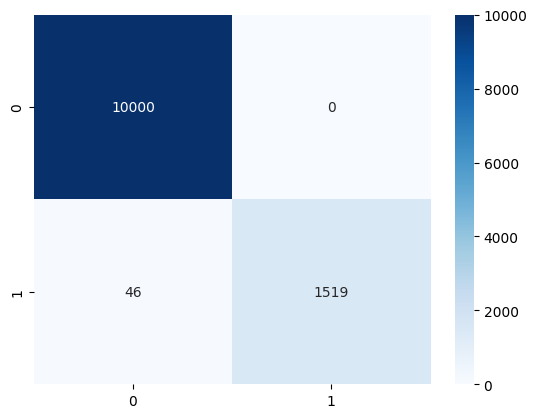

: 

In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset from the correct folder
data = pd.read_csv("../data/processed/phishing_dataset.csv")


y_true = data["label"]

# Load saved model + vectorizer
model = joblib.load("../models/phishing_detector.pkl")
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

# Predict everything
preds = model.predict(vectorizer.transform(data["text"]))

# Display confusion matrix
sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='Blues')
plt.show()


In [31]:
def predict_email(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return "PHISHING" if pred == 1 else "LEGITIMATE"


In [32]:
predict_email("Your account has been suspended. Click here to verify.")


'PHISHING'

In [33]:
predict_email("I Have received the files, ill send an update soon.")


'PHISHING'

In [34]:
predict_email("Thank you.")


'PHISHING'

In [35]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2005
           1       1.00      0.96      0.98       308

    accuracy                           0.99      2313
   macro avg       1.00      0.98      0.99      2313
weighted avg       0.99      0.99      0.99      2313



In [36]:
predict_email("""
Hi Ibrahim,

Just confirming our meeting tomorrow at 10am.
Let me know if you need anything beforehand.

Thanks,
Sarah
""")


'LEGITIMATE'

In [37]:
predict_email("""
Your account has been suspended due to suspicious activity.
Please verify your identity immediately by clicking the link below.
Failure to do so will result in permanent closure.
""")


'PHISHING'

In [ ]:
def explain_prediction(text):
    text_lower = text.lower()

    reasons = []
    # phishing indicators
    if "verify" in text_lower or "confirm" in text_lower:
        reasons.append("Contains verification request.")
    if "suspend" in text_lower or "suspended" in text_lower:
        reasons.append("Mentions account suspension.")
    if "click" in text_lower or "link" in text_lower:
        reasons.append("Contains a link or click request.")
    if "urgent" in text_lower or "immediately" in text_lower:
        reasons.append("Uses urgency to pressure the user.")
    if "password" in text_lower:
        reasons.append("References password or login credentials.")
    # legitimate indicators
    if "meeting" in text_lower or "schedule" in text_lower:
        reasons.append("Mentions normal work scheduling.")
    if "thank" in text_lower or "regards" in text_lower:
        reasons.append("Contains polite closing or signature.")
    if "tomorrow" in text_lower or "today" in text_lower:
        reasons.append("Contains normal conversational context.")

    if not reasons:
        reasons.append("No strong indicators detected.")

    return reasons


In [39]:
def analyze_email(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]

    label = "PHISHING" if pred == 1 else "LEGITIMATE"
    reasons = explain_prediction(text)

    return label, reasons


In [40]:
def generate_html_report(text):
    label, reasons = analyze_email(text)

    html = f"""
    <html>
    <head>
        <title>Email Analysis Report</title>
        <style>
            body {{ font-family: Arial; padding: 20px; }}
            .result {{ font-size: 24px; font-weight: bold; }}
            .phishing {{ color: red; }}
            .legitimate {{ color: green; }}
            ul {{ font-size: 18px; }}
        </style>
    </head>
    <body>
        <h1>Email Analysis Report</h1>
        <p class="result {'phishing' if label=='PHISHING' else 'legitimate'}">
            Result: {label}
        </p>
        <h2>Reasons:</h2>
        <ul>
            {''.join(f'<li>{reason}</li>' for reason in reasons)}
        </ul>
        <h2>Original Email:</h2>
        <pre>{text}</pre>
    </body>
    </html>
    """

    with open("email_report.html", "w", encoding="utf-8") as f:
        f.write(html)

    print("HTML report generated: email_report.html")


In [41]:
generate_html_report("Your account has been suspended. Click the link to verify.")


HTML report generated: email_report.html


In [4]:
# Combine legitimate and phishing emails
all_emails = legit_emails + phishing_emails

print("Total combined emails:", len(all_emails))



NameError: name 'legit_emails' is not defined

In [5]:
import pandas as pd

df_legit = pd.read_csv("../data/processed/legit_emails.csv")
legit_emails = df_legit.values.tolist()



FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/legit_emails.csv'

In [6]:
len(legit_emails)


NameError: name 'legit_emails' is not defined

In [7]:
'legit_emails' in globals()


False

In [8]:
import pandas as pd

df_legit = pd.DataFrame(legit_emails, columns=["text", "label"])
df_legit.to_csv("../data/processed/legit_emails.csv", index=False)

print("Saved legit_emails.csv")


NameError: name 'legit_emails' is not defined